In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd
import glob

In [2]:
import os

data_folder = "./maximas_data"
# data is structured as: f"{name}-{stamp}
# Get all files in the data folder
files = os.listdir(data_folder)

# Extract names and stamps from filenames
names = set()
stamps = set()

for file in files:
    if '-' in file:
        parts = file.split('-')
        if len(parts) >= 2:
            name = parts[0]
            stamp = parts[1].split('.')[0]  # Remove file extension if present
            names.add(name)
            stamps.add(stamp)

print(f"Unique names: {sorted(names)}")
print(f"Unique stamps: {sorted(stamps)}")



Unique names: ['series0', 'series1', 'series2', 'series3']
Unique stamps: ['64156931', '64156932']


In [3]:
maximas_data = {}
for name in names:
    path_pattern = f"{data_folder}/{name}-*.parquet"
    if glob.glob(path_pattern):
        ddf = dd.read_parquet(path_pattern)
        maximas_data[name] = ddf

In [4]:
points_per_series = 655360
points_per_block = points_per_series // 10

disjoint_maximas = {}

def sample_every_n(df, step):
    return df.iloc[::step]

for name in maximas_data.keys():
    sampled = maximas_data[name].map_partitions(sample_every_n, step=points_per_block)
    disjoint_maximas[name] = sampled.compute()

In [5]:
import sys
display(f"the size of the disjoint maximas is {sys.getsizeof(disjoint_maximas[name]) / 1024**2} MB")

'the size of the disjoint maximas is 0.000156402587890625 MB'

In [6]:
# Dictionary to store mean estimators
standard_disjoint_estimator = {}
# Dictionary to store standard deviation estimators
standard_disjoint_std_estimator = {}

for name in disjoint_maximas.keys():
    # Group by every 10 points
    grouped = disjoint_maximas[name].groupby(disjoint_maximas[name].index // 10)
    # Calculate mean for each group
    standard_disjoint_estimator[name] = grouped.mean()
    # Calculate standard deviation for each group
    standard_disjoint_std_estimator[name] = grouped.std(ddof=1)

# Dictionary to store bootstrap mean estimators
bs_disjoint_estimator = {}
# Dictionary to store bootstrap standard deviation estimators
bs_disjoint_std_estimator = {}

for name in disjoint_maximas.keys():
    # For bootstrap, we need to work with computed data (Pandas DataFrame)
    df_computed = disjoint_maximas[name]
    result_mean = {}
    result_std = {}
    
    # Group the data by every 10 points
    groups = df_computed.groupby(df_computed.index // 10)
    
    # For each group, perform bootstrap sampling
    for group_idx, group_data in groups:
        values = group_data['value'].values
        # Bootstrap with 100 samples for mean
        bootstrap_means = np.array([np.random.choice(values, size=len(values), replace=True).mean() 
                                   for _ in range(100)])
        # Bootstrap with 100 samples for standard deviation
        bootstrap_stds = np.array([np.std(np.random.choice(values, size=len(values), replace=True), ddof=1) 
                                  for _ in range(100)])
        
        result_mean[group_idx] = bootstrap_means.mean()
        result_std[group_idx] = bootstrap_stds.mean()
    
    # Convert the results to DataFrames
    bs_disjoint_estimator[name] = pd.DataFrame({'value': pd.Series(result_mean)})
    bs_disjoint_std_estimator[name] = pd.DataFrame({'value': pd.Series(result_std)})

/home/groups/gorle/codes/miniconda3/envs/nickCookMayne/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


KeyError: 'value'

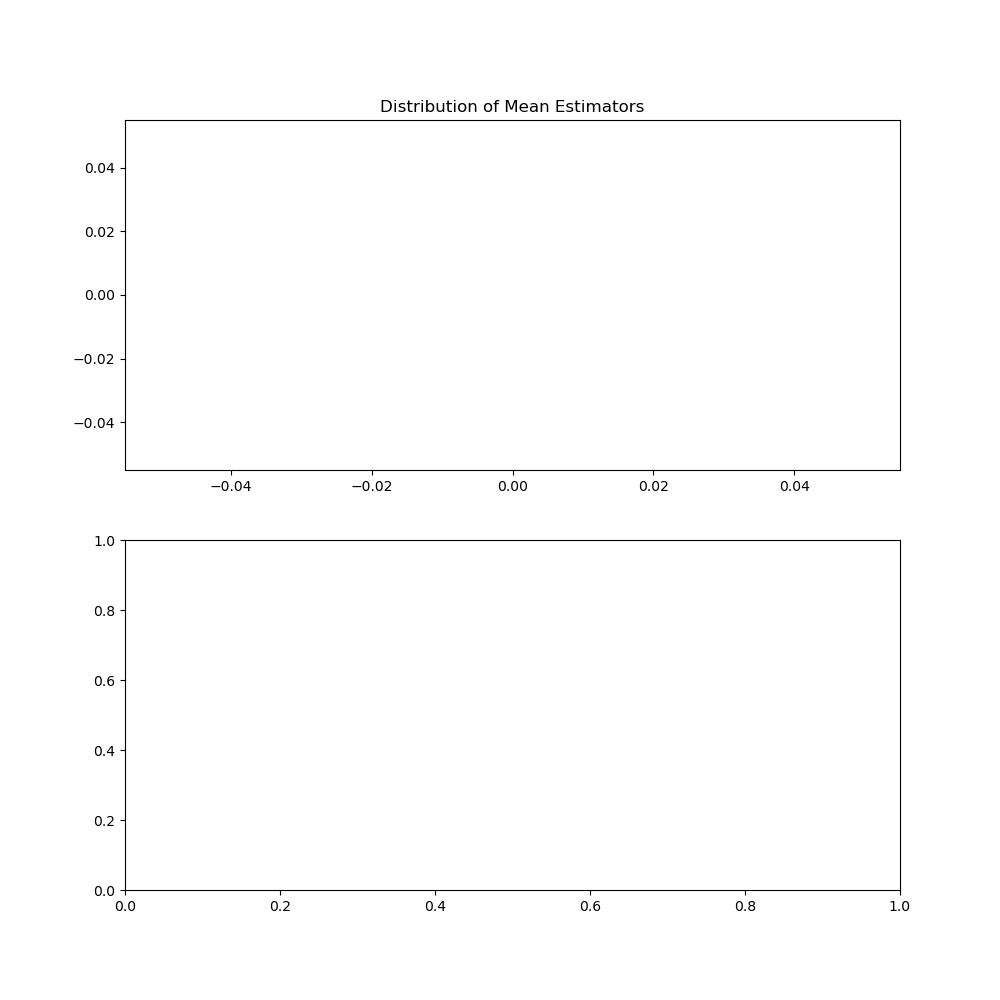

In [7]:
# Create a figure with two subplots - one for mean and one for std dev
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot for means
ax1.set_title("Distribution of Mean Estimators")
for name, df in standard_disjoint_estimator.items():
    # plot the empirical pdf of the standard estimator
    ax1.hist(df, bins=100, density=True, alpha=0.5, label=f"{name} (Standard)")
    # plot a vertical line at the mean
    mean = df.mean()
    ax1.axvline(mean['value'], color='r', linestyle='--', label=f"{name} standard mean")

# Plot the bootstrap mean estimator
for name, df in bs_disjoint_estimator.items():
    # plot the empirical pdf of the bootstrap estimator
    ax1.hist(df, bins=100, density=True, alpha=0.5, label=f"{name} (Bootstrap)")
    # plot a vertical line at the mean
    mean = df.mean()
    ax1.axvline(mean['value'], color='g', linestyle='--', label=f"{name} bootstrap mean")

for name, df in disjoint_maximas.items():
    # plot the empirical pdf of the disjoint maximas
    ax1.hist(df, bins=100, density=True, alpha=0.5, label=f"{name} (Original)")
    # plot a vertical line at the mean
    mean = df.mean()
    ax1.axvline(mean['value'], color='k', linestyle='--', label=f"{name} mean")

ax1.legend(loc='upper right', fontsize='small')

# Plot for standard deviations
ax2.set_title("Distribution of Standard Deviation Estimators")
for name in disjoint_maximas.keys():
    # Plot a vertical line at the overall standard deviation
    overall_std = disjoint_maximas[name]['value'].std(ddof=1)
    ax2.axvline(overall_std, color='k', linestyle='--', label=f"{name} overall StdDev")

for name, df in standard_disjoint_std_estimator.items():
    # Plot the empirical pdf of the standard estimator for std dev
    ax2.hist(df, bins=100, density=True, alpha=0.5, label=f"{name} (Standard StdDev)")

# Plot the bootstrap std dev estimator
for name, df in bs_disjoint_std_estimator.items():
    # Plot the empirical pdf of the bootstrap estimator for std dev
    ax2.hist(df, bins=100, density=True, alpha=0.5, label=f"{name} (Bootstrap StdDev)")

ax2.legend(loc='upper right', fontsize='small')

plt.tight_layout()

In [ ]:
import numpy as np
import pandas as pd

# Function to calculate bias, standard error, and MSE for both mean and std dev
def calculate_metrics(estimator, true_value, metric_type="mean"):
    """
    Calculate bias, standard error, and MSE for an estimator.
    
    Parameters:
    -----------
    estimator : pandas.DataFrame
        DataFrame containing the estimates
    true_value : float
        The true value (mean or std dev)
    metric_type : str
        Type of metric ("mean" or "std")
    
    Returns:
    --------
    dict
        Dictionary containing bias, standard error, and MSE
    """
    values = estimator['value'].values
    bias = np.mean(values) - true_value
    standard_error = np.std(values, ddof=1)
    mse = np.mean((values - true_value)**2)
    
    return {
        'bias': bias,
        'standard_error': standard_error,
        'mse': mse,
        'metric_type': metric_type
    }

# Function to compare estimators for both mean and std dev
def compare_estimators(true_df, mean_estimators_dict, std_estimators_dict, name):
    """
    Compare multiple estimators against a true dataset for both mean and std dev.
    
    Parameters:
    -----------
    true_df : pandas.DataFrame
        DataFrame containing the true data
    mean_estimators_dict : dict
        Dictionary of mean estimators, with keys as estimator names
    std_estimators_dict : dict
        Dictionary of std dev estimators, with keys as estimator names
    name : str
        Name of the dataset being evaluated
    
    Returns:
    --------
    dict
        Results dictionary with metrics for each estimator
    """
    # Calculate the true mean and std dev
    true_mean = true_df['value'].mean()
    true_std = true_df['value'].std(ddof=1)
    
    print(f"\nMetrics for {name}:")
    print(f"Reference mean: {true_mean:.6f}")
    print(f"Reference std dev: {true_std:.6f}")
    
    results = {'true_mean': true_mean, 'true_std': true_std}
    
    # Calculate metrics for each mean estimator
    print("\nMean Estimators:")
    for estimator_name, estimator_df in mean_estimators_dict.items():
        metrics = calculate_metrics(estimator_df, true_mean, "mean")
        print(f"\n{estimator_name} Mean Estimator:")
        print(f"  Bias: {metrics['bias']:.6f}")
        print(f"  Standard Error: {metrics['standard_error']:.6f}")
        print(f"  MSE: {metrics['mse']:.6f}")
        
        results[f"{estimator_name}_mean"] = metrics
    
    # Calculate metrics for each std dev estimator
    print("\nStandard Deviation Estimators:")
    for estimator_name, estimator_df in std_estimators_dict.items():
        metrics = calculate_metrics(estimator_df, true_std, "std")
        print(f"\n{estimator_name} StdDev Estimator:")
        print(f"  Bias: {metrics['bias']:.6f}")
        print(f"  Standard Error: {metrics['standard_error']:.6f}")
        print(f"  MSE: {metrics['mse']:.6f}")
        
        results[f"{estimator_name}_std"] = metrics
    
    return results

# Process all datasets
all_results = {}
for name in disjoint_maximas.keys():
    # Create dictionaries of estimators to compare
    mean_estimators = {}
    std_estimators = {}
    
    if name in standard_disjoint_estimator:
        mean_estimators['Standard'] = standard_disjoint_estimator[name]
    if name in bs_disjoint_estimator:
        mean_estimators['Bootstrap'] = bs_disjoint_estimator[name]
    
    if name in standard_disjoint_std_estimator:
        std_estimators['Standard'] = standard_disjoint_std_estimator[name]
    if name in bs_disjoint_std_estimator:
        std_estimators['Bootstrap'] = bs_disjoint_std_estimator[name]
    
    # Compare the estimators
    all_results[name] = compare_estimators(disjoint_maximas[name], mean_estimators, std_estimators, name)

# Create a summary table for comparison
summary_df = pd.DataFrame(columns=['Dataset', 'Estimator', 'Metric Type', 'Bias', 'Standard Error', 'MSE'])

row = 0
for dataset, results in all_results.items():
    for key, metrics in results.items():
        if key not in ['true_mean', 'true_std']:
            estimator_name = key.split('_')[0]
            metric_type = metrics['metric_type'] if 'metric_type' in metrics else key.split('_')[1]
            
            summary_df.loc[row] = [
                dataset, 
                estimator_name,
                metric_type,
                metrics['bias'] if 'bias' in metrics else None,
                metrics['standard_error'] if 'standard_error' in metrics else None,
                metrics['mse'] if 'mse' in metrics else None
            ]
            row += 1

if len(summary_df) > 0:
    print("\nSummary Table:")
    print(summary_df)

In [ ]:
# Plot the comparison of estimation errors for both mean and std dev
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Plot Mean Estimation Errors
for dataset, results in all_results.items():
    # Extract metrics for mean estimators
    estimators = []
    biases = []
    mses = []
    
    for key, metrics in results.items():
        if key not in ['true_mean', 'true_std'] and key.endswith('_mean'):
            estimator_name = key.split('_')[0]
            estimators.append(estimator_name)
            biases.append(abs(metrics['bias']))
            mses.append(metrics['mse'])
    
    # Plot the metrics
    x = np.arange(len(estimators))
    width = 0.35
    
    ax1.bar(x - width/2, biases, width, label=f'{dataset} Bias')
    ax1.bar(x + width/2, mses, width, label=f'{dataset} MSE')
    
    ax1.set_ylabel('Error Value')
    ax1.set_title('Mean Estimation Errors')
    ax1.set_xticks(x)
    ax1.set_xticklabels(estimators)
    ax1.legend()

# Plot StdDev Estimation Errors
for dataset, results in all_results.items():
    # Extract metrics for std dev estimators
    estimators = []
    biases = []
    mses = []
    
    for key, metrics in results.items():
        if key not in ['true_mean', 'true_std'] and key.endswith('_std'):
            estimator_name = key.split('_')[0]
            estimators.append(estimator_name)
            biases.append(abs(metrics['bias']))
            mses.append(metrics['mse'])
    
    # Plot the metrics
    x = np.arange(len(estimators))
    width = 0.35
    
    ax2.bar(x - width/2, biases, width, label=f'{dataset} Bias')
    ax2.bar(x + width/2, mses, width, label=f'{dataset} MSE')
    
    ax2.set_ylabel('Error Value')
    ax2.set_title('Standard Deviation Estimation Errors')
    ax2.set_xticks(x)
    ax2.set_xticklabels(estimators)
    ax2.legend()

plt.tight_layout()
plt.show()